In [2]:
import pandas as pd
import numpy as np

In [3]:
jack_df = pd.read_csv('jacks-ztf-transients.csv')

In [4]:
full_df = pd.read_csv('final_full_data_centered.csv')

In [6]:
ia_plots

NameError: name 'ia_plots' is not defined

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_transient_epochs_flux(df, name,
                               name_col="Name",
                               epoch_col="Epoch",
                               path_col="File Path",
                               rms_col="RMS_mjy",
                               peak_col="Flux_mjy",
                               dt_col="Rest_DeltaT",
                               cmap="inferno",
                               border_snr_threshold=4,
                               border_color="lime",
                               savepath=None):
    """
    Plot all available epochs for a transient in a single row,
    using stored RMS and Peak FLUX columns (does NOT recompute).

    Formatting matches your luminosity plot:
      - Title: Name, Epoch, Δt
      - X label: RMS, Max Flux, S/N
      - Lime border if S/N > threshold
    """

    g = df[df[name_col] == name].copy()
    if len(g) == 0:
        raise ValueError(f"No rows found for object '{name}'")

    g = g.sort_values(epoch_col)
    n = len(g)

    fig, axs = plt.subplots(1, n, figsize=(4*n, 4), constrained_layout=True)
    if n == 1:
        axs = [axs]

    fig.suptitle(name, fontsize=14)

    for ax, (_, row) in zip(axs, g.iterrows()):
        path = row[path_col]

        if not os.path.exists(path):
            ax.set_title("Missing file")
            ax.axis("off")
            continue

        arr = np.load(path)

        rms = row[rms_col]
        peak = row[peak_col]
        snr = peak / rms if rms != 0 else np.nan

        epoch = row[epoch_col]
        delta_t = row.get(dt_col, np.nan)

        ax.imshow(arr, cmap=cmap, interpolation="nearest")

        ax.set_title(
            f"{name}: Epoch {epoch}, Δt: {delta_t:.0f}d",
            fontsize=9
        )

        ax.set_xlabel(
        "RMS: {:.3g} mJy, Max Flux: {:.3g} mJy\nS/N: {:.3f}".format(rms, peak, snr),
        fontsize=9
)

        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

        if np.isfinite(snr) and snr > border_snr_threshold:
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(4)
        else:
            for spine in ax.spines.values():
                spine.set_edgecolor("black")
                spine.set_linewidth(1)

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()
    return fig, axs

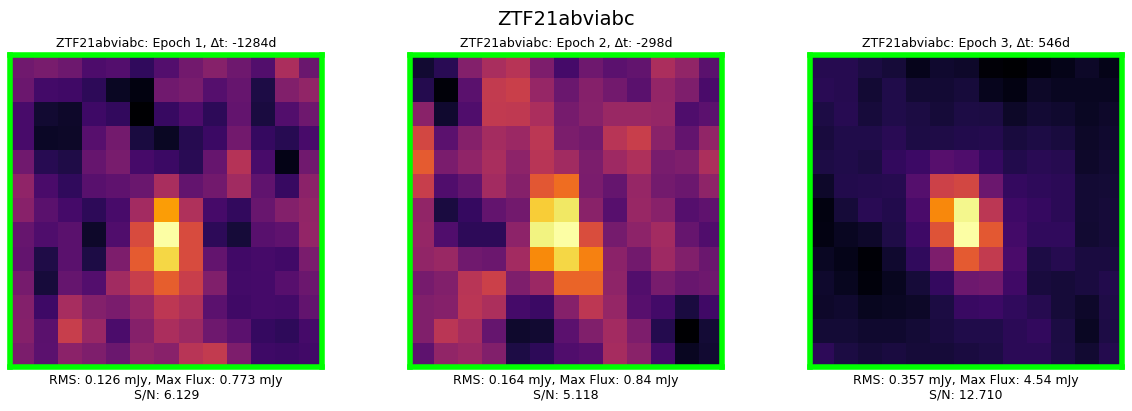

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'ZTF21abviabc: Epoch 1, Δt: -1284d'}, xlabel='RMS: 0.126 mJy, Max Flux: 0.773 mJy\nS/N: 6.129'>,
        <Axes: title={'center': 'ZTF21abviabc: Epoch 2, Δt: -298d'}, xlabel='RMS: 0.164 mJy, Max Flux: 0.84 mJy\nS/N: 5.118'>,
        <Axes: title={'center': 'ZTF21abviabc: Epoch 3, Δt: 546d'}, xlabel='RMS: 0.357 mJy, Max Flux: 4.54 mJy\nS/N: 12.710'>],
       dtype=object))

In [16]:
plot_transient_epochs_flux(full_df, 'ZTF21abviabc')

In [7]:
plot_transient_epochs_flux(full_df, 'ZTF19aakswrb')

NameError: name 'plot_transient_epochs_flux' is not defined